#### Requirements

In [1]:
# Run this cell to install some required packages:
!pip install keras-nlp pydot bertviz

# Visualizing the flow of a model

### Demonstrating projection

2025-05-28 22:23:46.738170: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-05-28 22:23:46.738224: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-05-28 22:23:46.738235: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-05-28 22:23:46.738433: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-28 22:23:46.738451: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


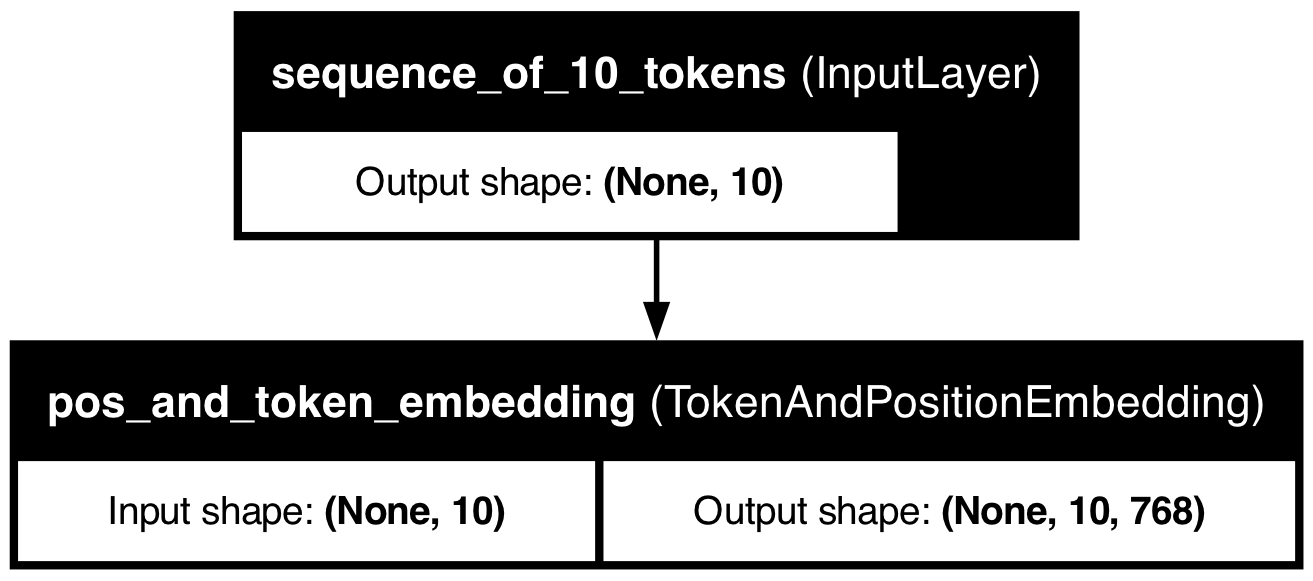

In [2]:
from keras_nlp.layers import TokenAndPositionEmbedding
from tensorflow.keras.layers import Input, LayerNormalization, Dense, Embedding
from tensorflow.keras import Sequential, Model
import tensorflow as tf

# Imagine an input sequence of 10 tokens
input_layer = Input(shape = (10,), name = "sequence_of_10_tokens")
# This layer takes our tokens and gives them both word and pos embeddings
embedding_layer = TokenAndPositionEmbedding(20, 10, 768, name = "pos_and_token_embedding")(input_layer)

# For visualization purposes
first_embeddings = Model(inputs = input_layer, outputs = embedding_layer)
tf.keras.utils.plot_model(first_embeddings,  show_shapes=True, show_layer_names=True)

### Demonstrating passing to FFN

In [ ]:
# # Queries x Keys
# dot_product = tf.matmul(query, key, transpose_b=True, name = "dot_product_q_k")
# # Scale
# scaled_dot_product = dot_product / 768 ** 0.5
# # Softmax
# softmaxed = tf.nn.softmax(scaled_dot_product, name = "apply_softmax")
# # Multiply by Values
# z = tf.matmul(softmaxed, value, name = "multiply_scores_w_value")

# # For visualization purposes
# partial_block = Model(inputs = input_layer, outputs = z)


import tensorflow as tf
from keras.layers import Input, Embedding, Dense, Dot, Softmax
from keras.models import Model

# Toy hyper-params
seq_len     = 10          # length of the input sentence
vocab_size  = 50          # let's assume
d_model     = 768         # projection size = dₖ = dᵥ = 768 in your snippet

# ----- model -----
input_layer      = Input(shape=(seq_len,), dtype="int32", name="sequence_of_10_tokens")
embedding_layer  = Embedding(vocab_size, d_model, name="token_embedding")(input_layer)

# Q, K, V projections
query  = Dense(d_model, name="query_projection")(embedding_layer)   # (batch, L, dₖ)
key    = Dense(d_model, name="key_projection")(embedding_layer)     # (batch, L, dₖ)
value  = Dense(d_model, name="value_projection")(embedding_layer)   # (batch, L, dᵥ)

print(f"The shape of query is {query.shape}.")
print(f"The shape of key is {key.shape}.")
print(f"The shape of value is {value.shape}.")


The shape of query is (None, 10, 768).
The shape of key is (None, 10, 768).
The shape of value is (None, 10, 768).


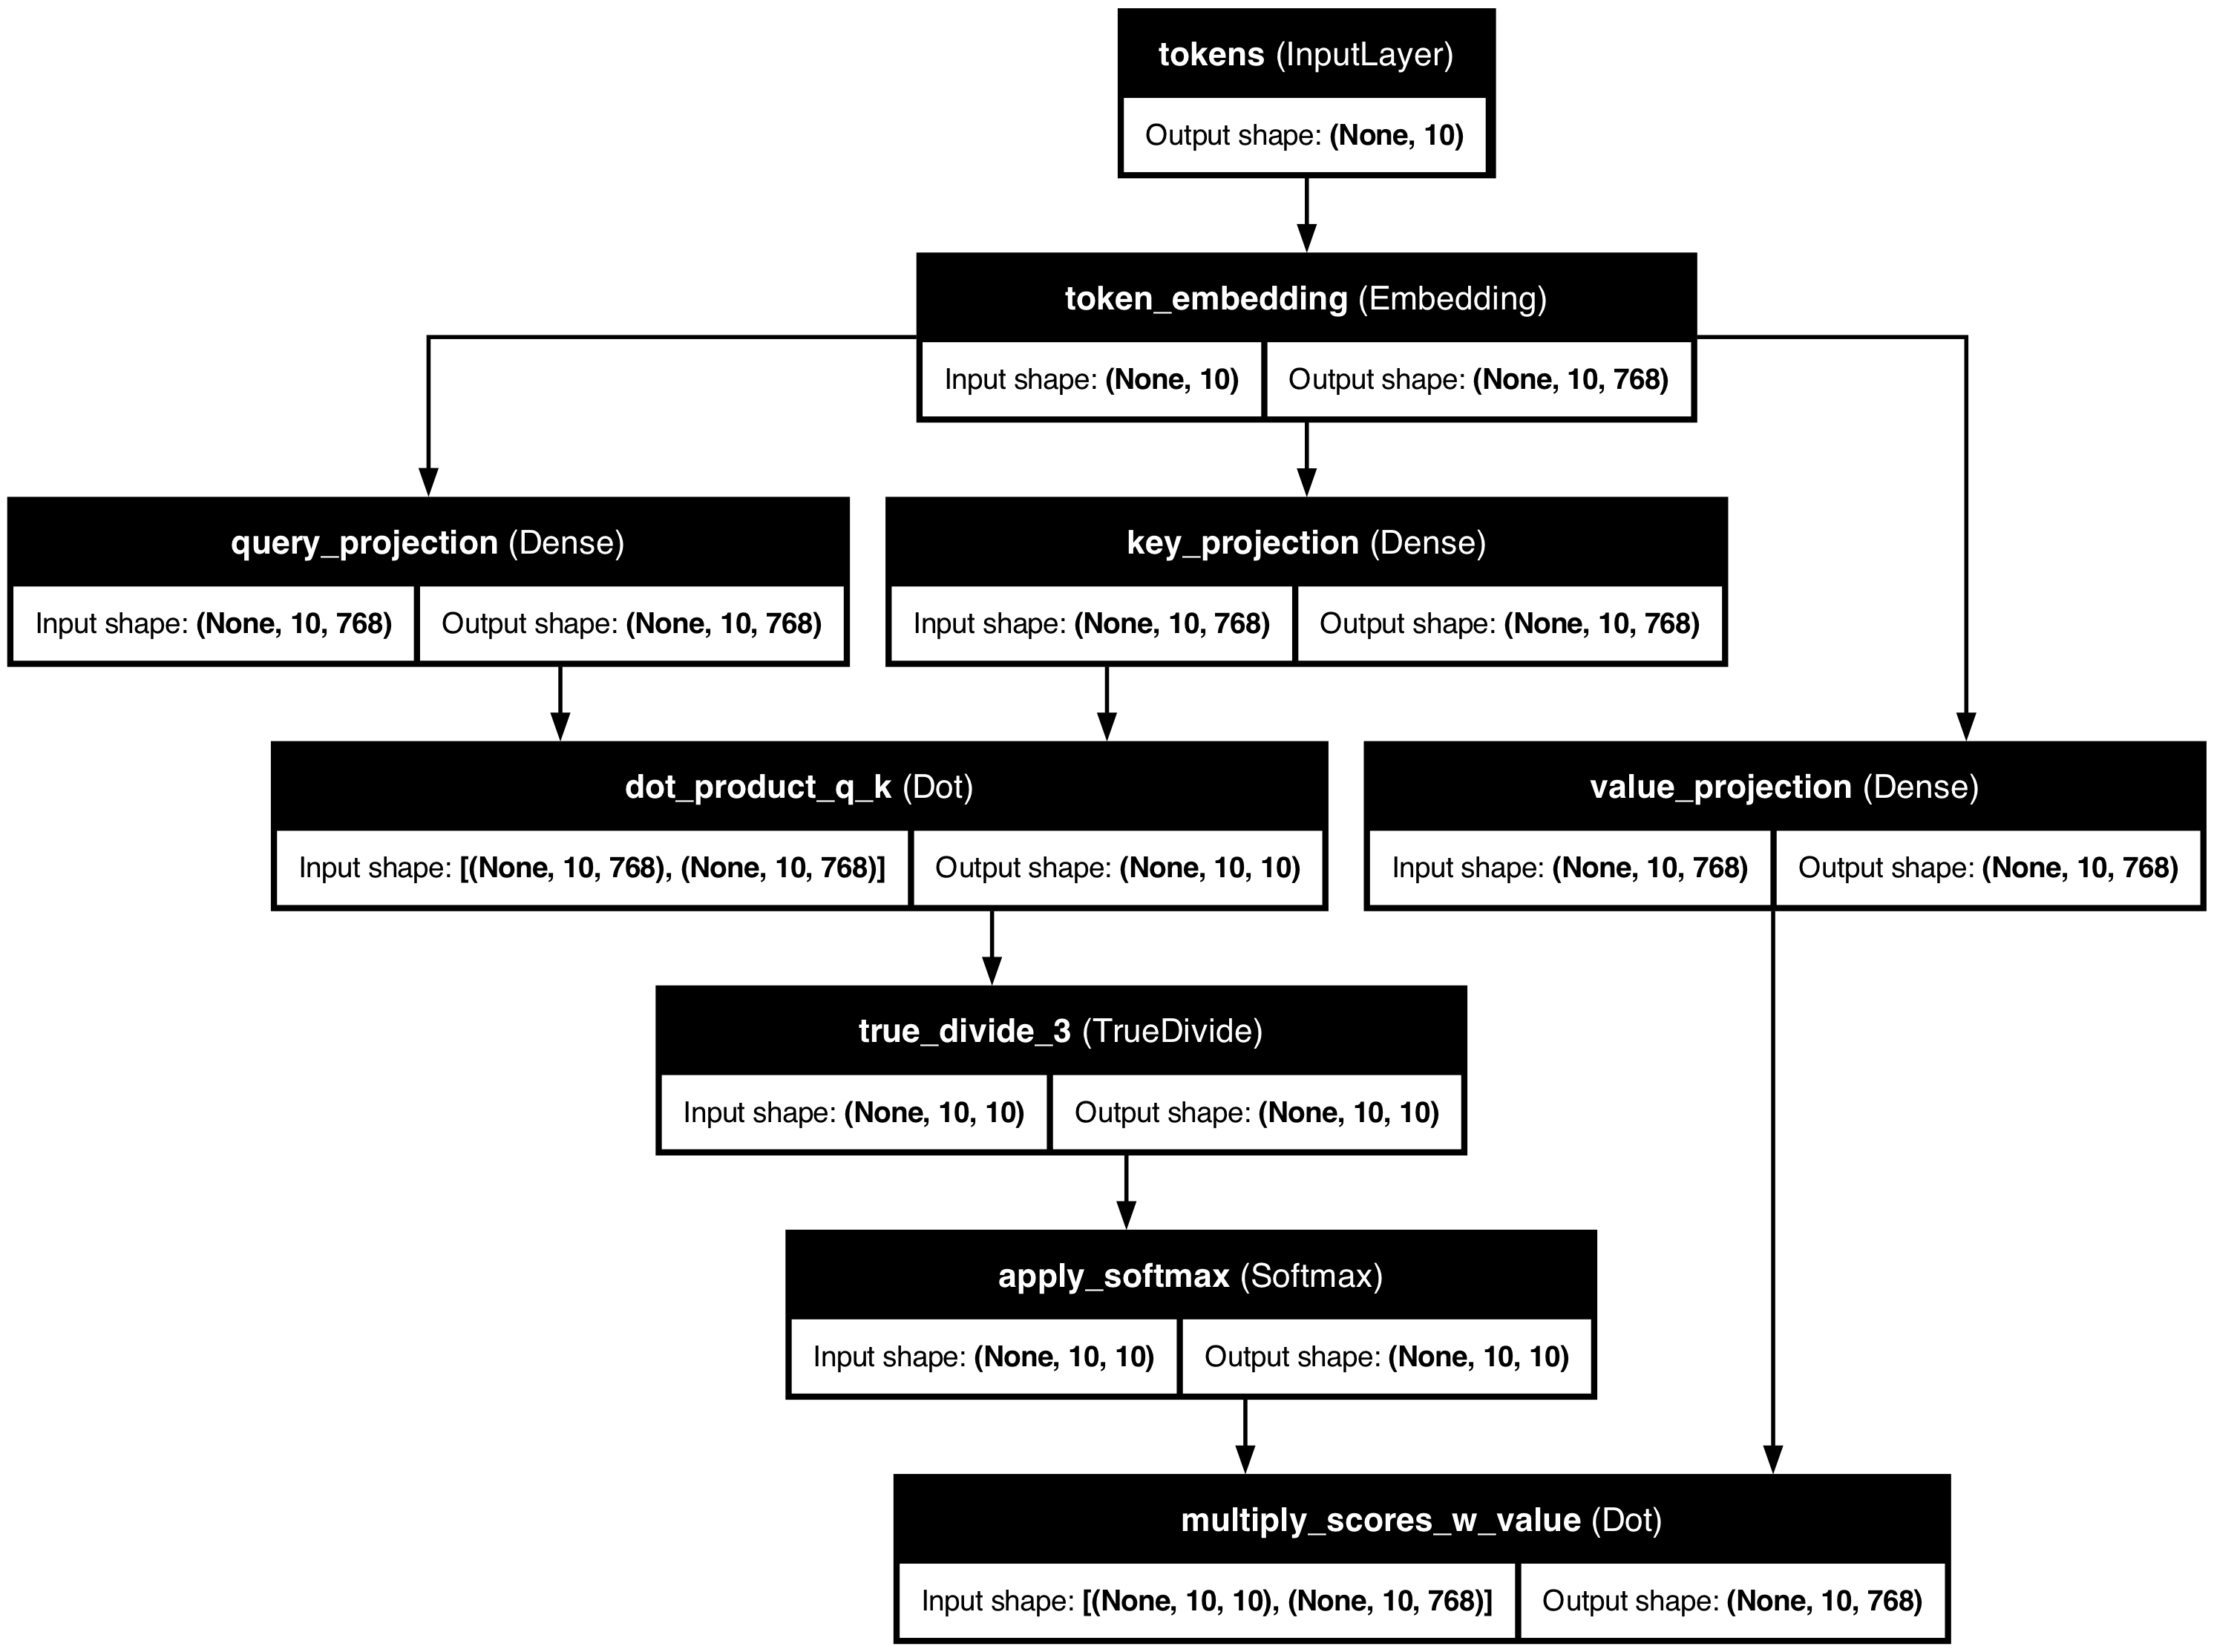

In [ ]:
#########################
# SIMILARITY SCORES     #
#########################

# 1️⃣  Dot product Q · Kᵀ   (no explicit transpose needed)
dot_product = Dot(axes=(2, 2),              # contract the dₖ axis of each tensor
                  name="dot_product_q_k")([query, key])
# dot_product = tf.matmul(query, key, transpose_b=True, name = "dot_product_q_k")
# → shape: (batch, L_q, L_k)  ==  (batch, L, L)

# 2️⃣  Scale by √dₖ
d_k =  tf.cast(query.shape[-1], tf.float32)  # == 2 here
scaled = dot_product / tf.math.sqrt(d_k)

# 3️⃣  Softmax over the key dimension (last axis)
attention_scores = Softmax(axis=-1, name="apply_softmax")(scaled)

#########################
# INFORMATION RETRIEVAL #
#########################

# 4️⃣  Scores × V   → Z
z = Dot(axes=(2, 1),               # contract L_k/L_v axis
        name="multiply_scores_w_value")([attention_scores, value])
# → shape: (batch, L_q, dᵥ) == (batch, L, 2)

# For visualisation / further stacking
partial_block = Model(inputs=input_layer, outputs=z)

tf.keras.utils.plot_model(partial_block,  show_shapes=True, show_layer_names=True)

### Putting it all together

In [ ]:
# Then we simply add some Dense layers and normalization
ff_1 = Dense(4 * 768, name = "first_feed_forward")(z)
ff_2 = Dense(768, name = "second_feed_forward")(ff_1)
ffn_output = tf.keras.layers.LayerNormalization(name = "normalize_mean_0_std_1")(ff_2)

# For visualization purposes
full_block = Model(inputs = input_layer, outputs = ffn_output)
tf.keras.utils.plot_model(full_block,  show_shapes=True, show_layer_names=True)

# Visualization with BertViz

In [ ]:
from bertviz import head_view
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("bert-base-uncased", output_attentions = True)

first_sentence = "The lawyer worked on the case"
second_sentence = "I pushed shift to make the letters upper case"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
viz_input = tokenizer(first_sentence, second_sentence, return_tensors = "pt")
attention = model(**viz_input).attentions
starter = (viz_input.token_type_ids == 0).sum(dim = 1)
tokens = tokenizer.convert_ids_to_tokens(viz_input.input_ids[0])
head_view(attention, tokens, starter, heads = [8])

# `transformers` pipelines

In [ ]:
from transformers import pipeline
pipe = pipeline("translation", model="Helsinki-NLP/opus-mt-en-fr")

In [ ]:
result = pipe("I am a student and I am studying in London")
result[0]['translation_text']

### Pipelines under the hood (a Tensorflow variation)

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")

tokens = tokenizer.encode("This is easy!", return_tensors = "tf")

print(tokens)

In [ ]:
model = TFAutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-fr", from_pt = True)

output_tokens = model.generate(tokens)

print(output_tokens)

print(tokenizer.decode(output[0]))